# Intent trends

Load intent-classified data from `intent_output/all` (full ~280k rows, single or chunked parquet) or from range subfolders (`0_10000`, `10000_20000`, …). Visualize **weekly** intent category and sub-category percentages over time. Timestamps are **UTC**. Later, after running `commercial_vertical_extraction.ipynb`, we can add visualizations per vertical.

In [1]:
# Control variables (edit and run first)
INTENT_OUTPUT_DIR = "intent_output"
LOAD_FROM_ALL = True   # if True, load from intent_output/all (full dataset); if False, load from range subfolders (0_10000, etc.)

## Load data

Load from `intent_output/all` (when LOAD_FROM_ALL) or from range subfolders (e.g. `0_10000/intent_classified_llm_0_10000.parquet`). The `all` folder may contain a single parquet or chunked files (e.g. `intent_classified_llm_all_0_50000.parquet`, …).

In [2]:
import pandas as pd
from pathlib import Path

from intent_analysis_utils import load_intent_from_range_folders
from intent_taxonomy import load_classified

if LOAD_FROM_ALL:
    all_dir = Path(INTENT_OUTPUT_DIR) / "all"
    df = load_classified(all_dir, full_name="intent_classified_llm_all.parquet")
else:
    df = load_intent_from_range_folders(INTENT_OUTPUT_DIR)
print(f"Loaded {len(df):,} rows. Columns: {list(df.columns)}")
if "timestamp" in df.columns:
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df.head(2)

Loaded 283,291 rows. Columns: ['conversation_id', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'text', 'intent_major', 'intent_sub']


,conversation_id,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted,text,intent_major,intent_sub
0,26c5dc109920789f9199ff9b37acb8c1,gpt-4,2023-04-10 00:01:08+00:00,"[{'content': 'Write a very long, elaborate, de...",1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0001022904907586053, 'i...",False,False,"Write a very long, elaborate, descriptive and ...",informational,creative_writing
1,e87a1aeb9aafa35c00da39ddeb1139a0,gpt-4,2023-04-10 00:01:10+00:00,"[{'content': 'what are you?', 'language': 'Eng...",1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 9.160337503999472e-05, 'i...",False,False,what are you?,informational,casual_other


## Weekly trends: intent categories (major)

Percentage of each **intent_major** category over time at weekly granularity. Title shows total number of data points.

/Users/Larry.Jin/Documents/research/wild_chat/intent_analysis_utils.py:197: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  out["period"] = pd.to_datetime(out[timestamp_col], utc=True).dt.to_period(freq).astype(str)


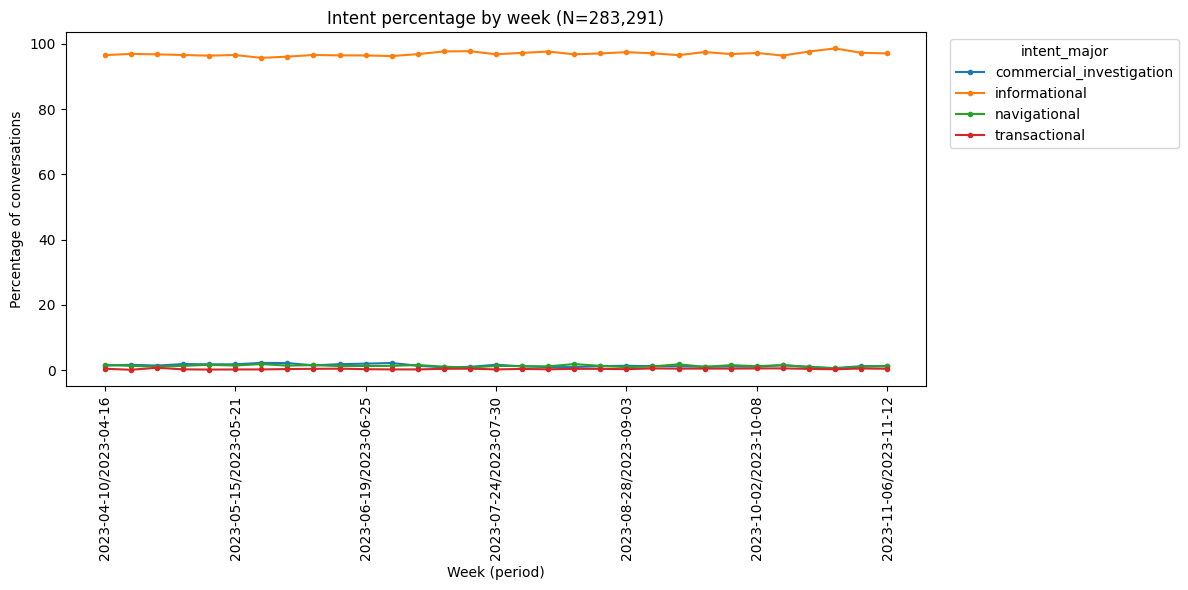

In [3]:
import matplotlib.pyplot as plt
from intent_analysis_utils import (
    weekly_intent_percentages,
    plot_weekly_intent_percentages,
)

if "intent_major" not in df.columns or df.empty:
    print("No intent_major or empty df; skipping.")
else:
    weekly_pct_major = weekly_intent_percentages(
        df, label_col="intent_major", timestamp_col="timestamp", freq="W"
    )
    n_total = len(df)
    plot_weekly_intent_percentages(
        weekly_pct_major,
        label_col="intent_major",
        total_n=n_total,
    )
    plt.show()

## Weekly trends: intent sub-categories

Percentage of each **intent_sub** over time at weekly granularity.

/Users/Larry.Jin/Documents/research/wild_chat/intent_analysis_utils.py:197: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  out["period"] = pd.to_datetime(out[timestamp_col], utc=True).dt.to_period(freq).astype(str)


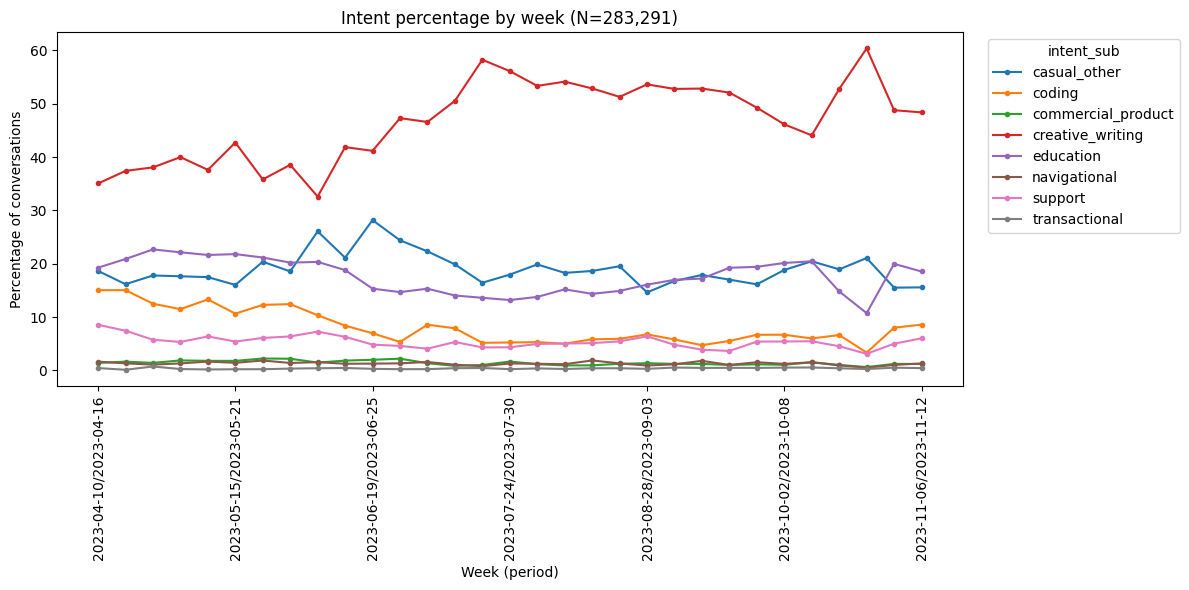

In [4]:
if "intent_sub" not in df.columns or df.empty:
    print("No intent_sub or empty df; skipping.")
else:
    weekly_pct_sub = weekly_intent_percentages(
        df, label_col="intent_sub", timestamp_col="timestamp", freq="W"
    )
    n_total = len(df)
    plot_weekly_intent_percentages(
        weekly_pct_sub,
        label_col="intent_sub",
        total_n=n_total,
    )
    plt.show()

## Weekly trends: commercial and transactional only

Separate plot for **commercial_investigation** and **transactional** only, since their share in the overall dataset may be low and hard to see in the full-category plot.

/Users/Larry.Jin/Documents/research/wild_chat/intent_analysis_utils.py:197: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  out["period"] = pd.to_datetime(out[timestamp_col], utc=True).dt.to_period(freq).astype(str)


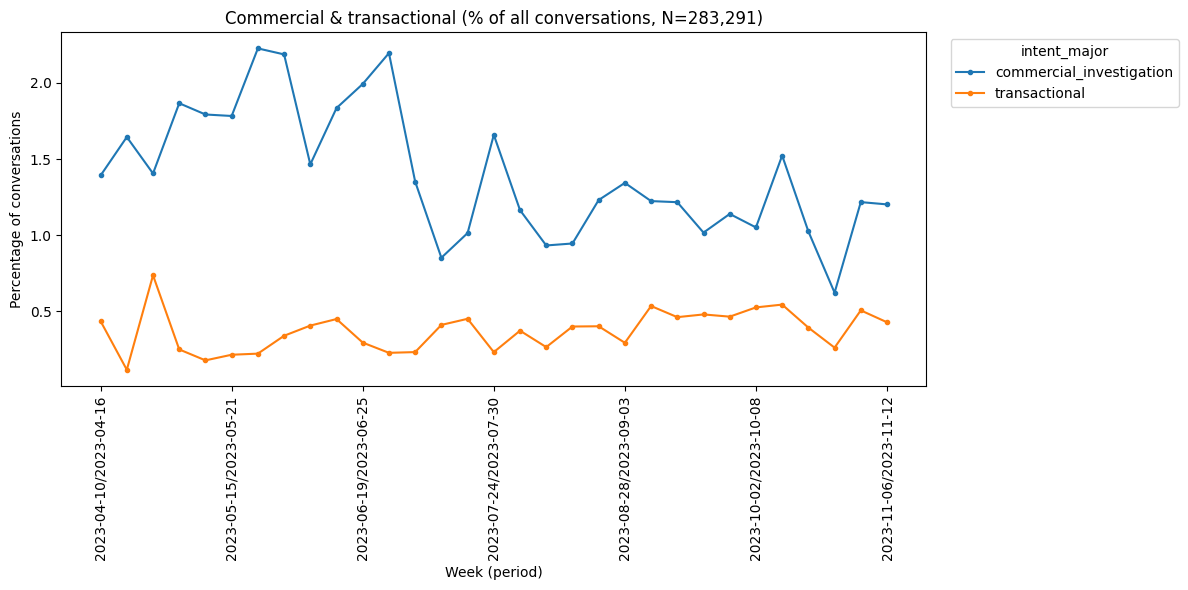

In [5]:
if "intent_major" not in df.columns or df.empty:
    print("No intent_major or empty df; skipping.")
else:
    # Compute weekly % from full dataset so y-axis is % of all conversations
    weekly_pct_major_full = weekly_intent_percentages(
        df, label_col="intent_major", timestamp_col="timestamp", freq="W"
    )
    weekly_pct_ct = weekly_pct_major_full[
        weekly_pct_major_full["intent_major"].isin(["commercial_investigation", "transactional"])
    ]
    if weekly_pct_ct.empty:
        print("No commercial_investigation or transactional rows; skipping.")
    else:
        n_total = len(df)
        plot_weekly_intent_percentages(
            weekly_pct_ct,
            label_col="intent_major",
            total_n=n_total,
            title=f"Commercial & transactional (% of all conversations, N={n_total:,})",
        )
        plt.show()